## Imports


In [40]:
!pip install brian2
from brian2 import *
from utils import *

start_scope()

## passive channel Bipolar neuron


In [41]:
length_thin = 200 *um
diameter_thin = 2 *um
compartments_thin = 0.05 * length_thin /um

# Morphology
morpho = Soma(20*um)
morpho.L = Cylinder(diameter=diameter_thin, length=length_thin, n=compartments_thin)
morpho.R = Cylinder(diameter=diameter_thin, length=length_thin, n=compartments_thin)

# Passive channels
gL = 1e-4*siemens/cm**2
EL = -70*mV
Es = 0*mV
eqs='''
Im = gL*(EL-v) : amp/meter**2
Is = (gs_L + gs_R) * (Es-v) : amp (point current)
gs_L : siemens
gs_R : siemens
'''

bipolar_neuron = SpatialNeuron(
    morphology=morpho,
    model=eqs,
    Cm=1*uF/cm**2,
    Ri=200*ohm*cm,
    method='exponential_euler'
)
neuron.v = EL

WARNING    The object 'spatialneuron' is getting deleted, but was never included in a network. This probably means that you did not store the object reference in a variable, or that the variable was not used to construct the network.
The object was created here (most recent call only):
  File '/tmp/ipykernel_5160/802133741.py', line 21, in <module>
    neuron = SpatialNeuron( [brian2.core.base.unused_brian_object]


## Generate input trains

In [42]:
N=6
f_stim_Hz=500
f_pre_Hz=350
tmax_ms=10
jitter_ms=0
itd_ms = 0.525 # for 90 deg

left_i, left_t = binomial_spike_train(
    N, f_stim_Hz, f_pre_Hz, tmax_ms, phase=0, jitter_ms=jitter_ms
)
right_i, right_t = binomial_spike_train(
    N, f_stim_Hz, f_pre_Hz, tmax_ms, phase=itd, jitter_ms=jitter_ms
)

print(f"Left spikes: {left_i} at time {left_t}")
print(f"Right spikes: {right_i} at time {right_t}")

# Shift times if negative
all_times = np.concatenate([left_t, right_t])
min_time = np.min(all_times)
if min_time < 0:
    left_t, right_t = left_t - min_time, right_t - min_time
    tmax_ms = tmax_ms - min_time


input_left = SpikeGeneratorGroup(N, left_i, left_t * ms)
input_right = SpikeGeneratorGroup(N, right_i, right_t * ms)




Left spikes: [0, 1, 4, 5, 0, 1, 2, 3, 4, 0, 1, 3, 4, 0, 1, 2, 3, 4, 5, 5] at time [0.0, 0.0, 0.0, 0.0, 2.0, 2.0, 2.0, 2.0, 2.0, 4.0, 4.0, 4.0, 4.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 8.0]
Right spikes: [0, 1, 2, 3, 4, 5, 1, 2, 3, 4, 5, 0, 3, 4, 5, 1, 2, 4, 5, 1, 3] at time [0.525, 0.525, 0.525, 0.525, 0.525, 0.525, 2.525, 2.525, 2.525, 2.525, 2.525, 4.525, 4.525, 4.525, 4.525, 6.525, 6.525, 6.525, 6.525, 8.525, 8.525]
SpikeGeneratorGroup(6, indices=<length 20 array>, times=<length 20 array>)


### plot sound wave function
 (not accurate just for fun and looking at phase-shift)

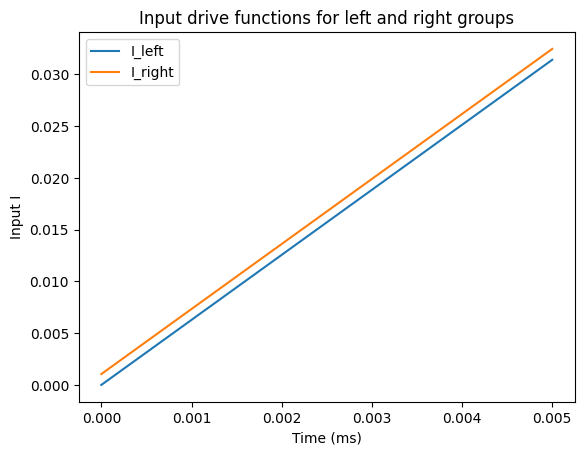

In [43]:
t_ms = np.linspace(0, 0.005, 1000)  # time i ms for plot
t_sec = t_ms/1000               # time in ms for I
A = 2

def I(A , f , phase_shift=0):
    # A = amplitude , f = frequency in Hz, phase_shift = phase_shift in ms
    return A * sin(2 * pi * f * t_sec + phase_shift/1000)

I_left = I(A, f_stim_Hz, 0)
I_right = I(A, f_stim_Hz, phase_shift=itd_ms)

plt.plot(t_ms, I_left, label="I_left")
plt.plot(t_ms, I_right, label="I_right")
plt.xlabel('Time (ms)')
plt.ylabel('Input I')
plt.title('Input drive functions for left and right groups')
plt.legend()
plt.show()

## Connecting the input to the bipolar neuron

In [ ]:
 # Synapse connections
syn_left = Synapses(input_left, neuron, on_pre="gsyn_post += w_syn / area_post")
syn_left.connect(i=range(N), j=left_index)
syn_right = Synapses(input_right, neuron, on_pre="gsyn_post += w_syn / area_post")
syn_right.connect(i=range(N), j=right_index)